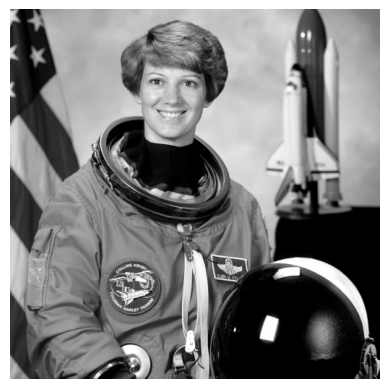

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import data

img = data.astronaut()
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# the original grayscale image
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

(-0.5, 511.5, 511.5, -0.5)

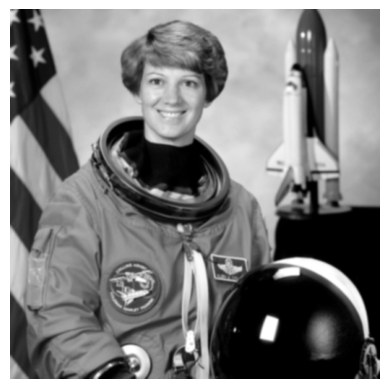

In [2]:
# apply Gaussian blur to the grayscale image
blur = cv2.GaussianBlur(gray_image, (5, 5), 0)
plt.imshow(blur, cmap='gray')
plt.axis('off')

(-0.5, 511.5, 511.5, -0.5)

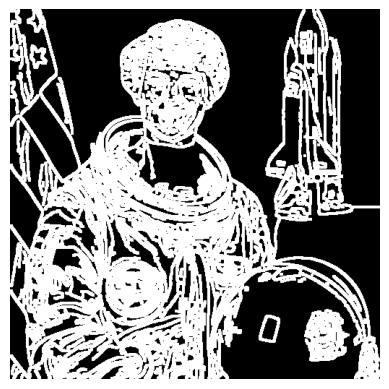

In [ ]:
# (lower values = more edges detected)
# threshold1=5: Lower bound for weak edges
# threshold2=40: Upper bound for strong edges
edges = cv2.Canny(blur, threshold1=5, threshold2=40)

# Kernel (3, 3): Small kernel to avoid excessive thickening
# iterations=1: Single pass for subtle thickening
kernel = np.ones((3, 3), np.uint8)  # Create a 3x3 matrix of 1s
edges = cv2.dilate(edges, kernel, iterations=1)  # Thicken edges

plt.imshow(edges, cmap='gray')
plt.axis('off')

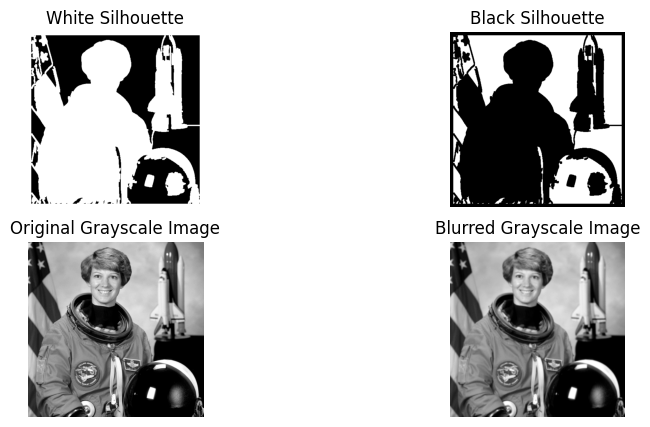

In [ ]:
# 找轮廓
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 创建黑色画布
silhouette1 = np.zeros_like(blur)
# 创建白色画布
silhouette2 = np.ones_like(blur) * 255


# 填充轮廓为白色
im1 = cv2.drawContours(silhouette1, contours, -1, 255, thickness=cv2.FILLED)
boardered1 = cv2.copyMakeBorder(im1, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=255)
# 填充轮廓为黑色
im2 = cv2.drawContours(silhouette2, contours, -1, 0, thickness=cv2.FILLED)
boardered2 = cv2.copyMakeBorder(im2, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=0)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))

ax[0,0].imshow(boardered1, cmap='gray')
ax[0,0].set_title('White Silhouette')
ax[0,0].axis('off')

ax[0,1].imshow(boardered2, cmap='gray')
ax[0,1].set_title('Black Silhouette')
ax[0,1].axis('off')

ax[1,0].imshow(gray_image, cmap='gray')
ax[1,0].set_title('Original Grayscale Image')
ax[1,0].axis('off')

ax[1,1].imshow(blur, cmap='gray')
ax[1,1].set_title('Blurred Grayscale Image')
ax[1,1].axis('off')

plt.show()

In [60]:
cv2.imwrite('jewelry_astronaut_white.png', boardered1)
cv2.imwrite('jewelry_astronaut_black.png', boardered2)

True